# Импорты и загрузка данных

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Путь к файлу
data_path = "S05-hw-dataset.csv"

# Загрузка данных
df = pd.read_csv(data_path)

# Первичный просмотр
display(df.head())
df.info()
df.describe()

# Распределение таргета
counts = df['default'].value_counts()
print("Target distribution:\n", counts)



,client_id,age,income,years_employed,credit_score,debt_to_income,num_credit_cards,num_late_payments,has_mortgage,has_car_loan,savings_balance,checking_balance,region_risk_score,phone_calls_to_support_last_3m,active_loans,customer_tenure_years,default
0,1,25,94074,22,839,0.547339,1,7,0,0,26057,5229,0.080052,19,1,8,0
1,2,58,51884,26,565,0.290882,1,1,0,1,16221,11595,0.428311,15,0,7,0
2,3,53,48656,39,561,0.522340,1,13,0,0,55448,-2947,0.770883,15,4,5,0
3,4,42,81492,30,582,0.709123,2,10,1,1,35188,17727,0.357619,0,2,7,1
4,5,42,94713,8,642,0.793392,3,3,0,0,0,-404,0.414260,17,1,10,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

# Распределение таргета (матplotlib)

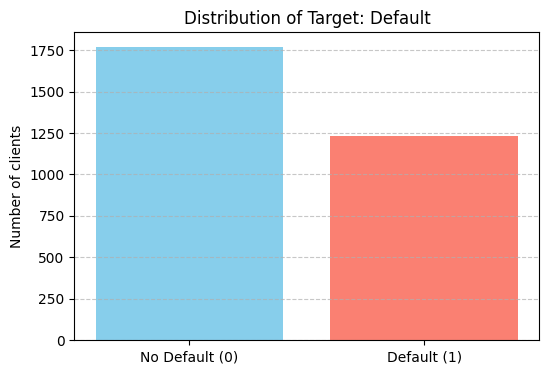

In [9]:
plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values, color=['skyblue', 'salmon'])
plt.xticks([0,1], ['No Default (0)', 'Default (1)'])
plt.ylabel('Number of clients')
plt.title('Distribution of Target: Default')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Подготовка признаков и таргета

In [10]:
# Матрица признаков и таргет
X = df.drop(columns=['client_id', 'default']).values  # numpy array
y = df['default'].values.reshape(-1,1)  # колонка для удобства

print("X shape:", X.shape)
print("y shape:", y.shape)



X shape: (3000, 15)
y shape: (3000, 1)


# Train/Test сплит

In [11]:
np.random.seed(42)

# Перемешиваем индексы
indices = np.arange(X.shape[0])
np.random.shuffle(indices)

# Размер теста 20%
test_size = int(0.2 * X.shape[0])
test_idx = indices[:test_size]
train_idx = indices[test_size:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])



Train size: 2400
Test size: 600


# Бейзлайн-модель (DummyClassifier)

In [12]:
# Находим наиболее частый класс на тренировке
most_freq = np.round(y_train.mean()).astype(int)  # 0 или 1

# Предсказания на тесте
y_dummy_pred = np.full_like(y_test, fill_value=most_freq)

# Accuracy
acc_dummy = (y_dummy_pred == y_test).mean()
print(f"DummyClassifier Accuracy: {acc_dummy:.3f}")




DummyClassifier Accuracy: 0.623


# Логистическая регрессия через Pipeline

In [13]:
# Функции
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y, y_pred):
    # бинарная кросс-энтропия
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1-eps)
    return -np.mean(y*np.log(y_pred) + (1-y)*np.log(1-y_pred))

# Нормализация признаков
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

# Добавим столбец единиц для bias
X_train_scaled = np.hstack([np.ones((X_train_scaled.shape[0],1)), X_train_scaled])
X_test_scaled = np.hstack([np.ones((X_test_scaled.shape[0],1)), X_test_scaled])

# Инициализация весов
w = np.zeros((X_train_scaled.shape[1],1))

# Градиентный спуск
lr = 0.1
epochs = 1000
for i in range(epochs):
    y_pred = sigmoid(X_train_scaled @ w)
    grad = X_train_scaled.T @ (y_pred - y_train) / X_train_scaled.shape[0]
    w -= lr * grad
    if i % 100 == 0:
        loss = compute_loss(y_train, y_pred)
        print(f"Epoch {i}, Loss: {loss:.4f}")




Epoch 0, Loss: 0.6931
Epoch 100, Loss: 0.4655
Epoch 200, Loss: 0.4513
Epoch 300, Loss: 0.4486
Epoch 400, Loss: 0.4480
Epoch 500, Loss: 0.4478
Epoch 600, Loss: 0.4477
Epoch 700, Loss: 0.4477
Epoch 800, Loss: 0.4477
Epoch 900, Loss: 0.4477


# Предсказания и метрики

In [21]:
# Прогноз вероятностей
y_proba = sigmoid(X_test_scaled @ w)
# Прогноз классов (порог 0.5)
y_pred = (y_proba >= 0.5).astype(int)

# Accuracy
acc = (y_pred == y_test).mean()
print(f"Logistic Regression Accuracy: {acc:.3f}")

def roc_auc_score_manual(y_true, y_scores):
    # сортируем по вероятностям
    desc_idx = np.argsort(-y_scores.flatten())
    y_true = y_true[desc_idx].flatten()
    n_pos = y_true.sum()
    n_neg = len(y_true) - n_pos
    tpr = np.cumsum(y_true)/n_pos
    fpr = np.cumsum(1 - y_true)/n_neg
    # добавляем нулевую точку
    tpr = np.hstack([[0], tpr])
    fpr = np.hstack([[0], fpr])
    # вычисляем AUC через np.trapezoid
    auc = np.trapezoid(tpr, fpr)
    return auc, fpr, tpr
    
roc, fpr, tpr = roc_auc_score_manual(y_test, y_proba)
print(f"Logistic Regression ROC-AUC: {roc:.3f}")


Logistic Regression Accuracy: 0.807
Logistic Regression ROC-AUC: 0.875


# ROC-кривая и сохранение графика

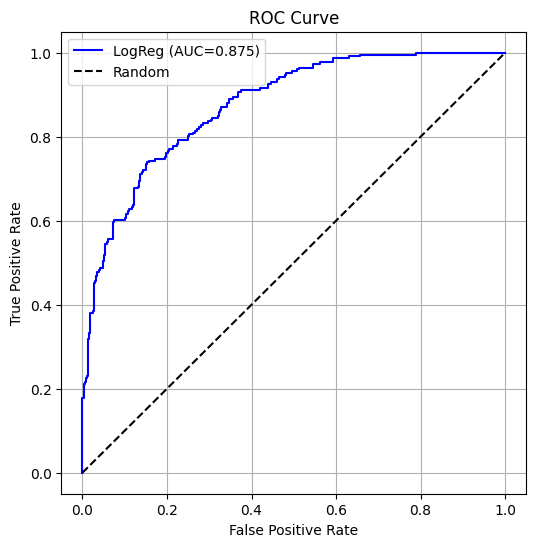

In [20]:
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'LogReg (AUC={roc:.3f})', color='blue')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()


In [16]:
# Confusion Matrix

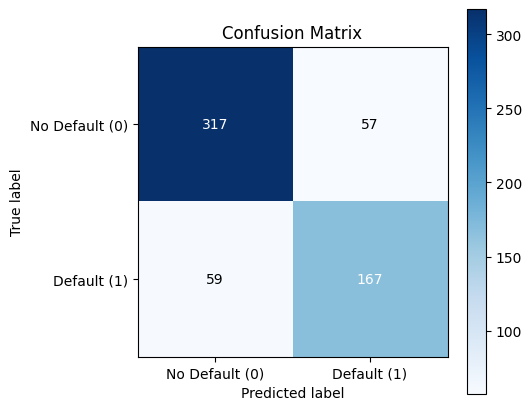

In [17]:
# Простая функция
def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true==1) & (y_pred==1))
    tn = np.sum((y_true==0) & (y_pred==0))
    fp = np.sum((y_true==0) & (y_pred==1))
    fn = np.sum((y_true==1) & (y_pred==0))
    return np.array([[tn, fp],
                     [fn, tp]])

cm = confusion_matrix_manual(y_test, y_pred)

plt.figure(figsize=(5,5))
plt.imshow(cm, cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ['No Default (0)','Default (1)'])
plt.yticks([0,1], ['No Default (0)','Default (1)'])
thresh = cm.max()/2
for i in range(2):
    for j in range(2):
        plt.text(j,i, cm[i,j], ha='center', va='center', 
                 color='white' if cm[i,j]>thresh else 'black')
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.show()



# Сравнение бейзлайна и логрег

In [18]:
results = pd.DataFrame({
    "Model": ["DummyClassifier", "LogisticRegression"],
    "Accuracy": [acc_dummy, acc],
    "ROC-AUC": [0.5, roc]  # DummyClassifier ROC-AUC ~0.5
})
print(results)



                Model  Accuracy   ROC-AUC
0     DummyClassifier  0.623333  0.500000
1  LogisticRegression  0.806667  0.875136
